In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_excel(r"C:\Users\Lenovo\OneDrive\Desktop\ft\project\1768299714153-ML Project - KNN Loan Applicant Credit Risk Analysis U 16955473070.xlsx")

In [5]:
data.head()

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
0,40.50,2,6,0.842666,594,0,0
1,41.25,5,2,0.791667,754,0,0
2,39.50,5,2,0.727273,779,0,0
3,35.00,1,4,0.820232,818,0,0
4,34.00,3,3,0.455581,853,0,1


In [8]:
# 2) Check for the null values
data.isnull().sum()

Age                           0
Total Work Experience         0
Number of years in city       0
Cost to Request Ratio         0
Cibil score                   0
Overdrafts past12months       0
Total bounces past12months    0
dtype: int64

In [13]:
# 3) Get basic information from data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         8995 non-null   float64
 1   Total Work Experience       8995 non-null   int64  
 2   Number of years in city     8995 non-null   int64  
 3   Cost to Request Ratio       8995 non-null   float64
 4   Cibil score                 8995 non-null   int64  
 5   Overdrafts past12months     8995 non-null   int64  
 6   Total bounces past12months  8995 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 492.0 KB


In [17]:
data.drop_duplicates(inplace=True)

In [18]:
# 4) Describe the dataset
data.describe()

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
count,8978.000000,8978.000000,8978.000000,8978.000000,8978.000000,8978.000000,8978.000000
mean,38.805081,2.129873,4.287703,0.831302,752.699933,0.322678,1.164959
std,10.204637,0.891743,1.269424,0.490604,67.574410,0.915757,2.354480
min,18.100000,1.000000,1.000000,0.008466,351.000000,0.000000,0.000000
25%,30.830000,1.000000,3.000000,0.662108,730.000000,0.000000,0.000000
50%,37.170000,2.000000,4.000000,0.800000,768.000000,0.000000,0.000000
75%,45.415000,3.000000,5.000000,0.931121,797.000000,0.000000,1.000000
max,83.800000,5.000000,6.000000,12.006623,882.000000,12.000000,12.000000


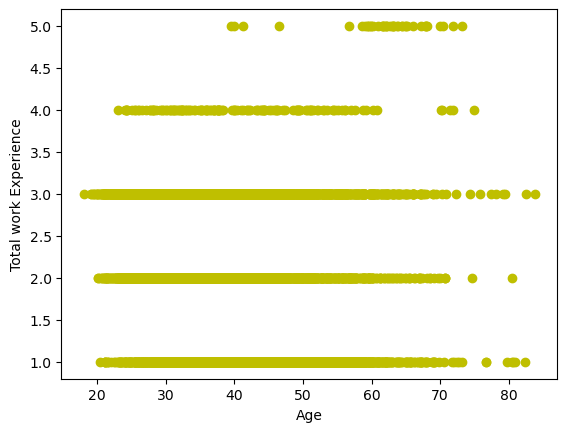

In [24]:
# 5) Display scatterplot between age & Total work Experience
plt.scatter(data["Age"],data["Total Work Experience"],c="y");
plt.xlabel("Age");
plt.ylabel('Total work Experience');

<Axes: ylabel='Age'>

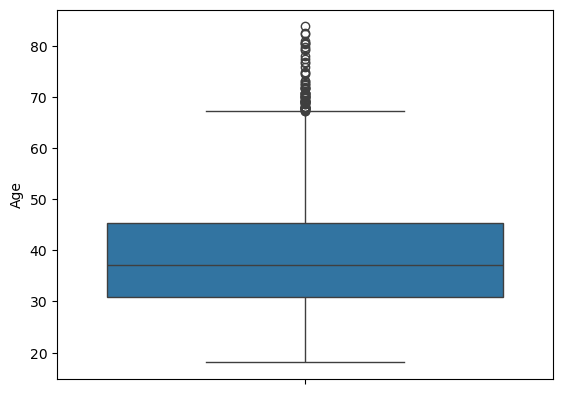

In [28]:
# 6) Display box plot for age
sns.boxplot(y=data["Age"])

<Axes: ylabel='Cibil score'>

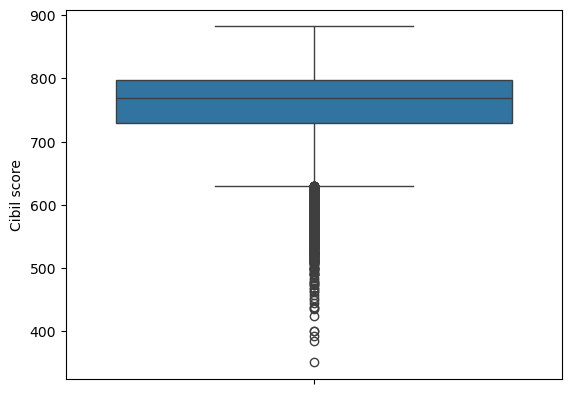

In [30]:
# 7) Display box plot for Cibil score
sns.boxplot(y=data["Cibil score"])

In [33]:
# 8) Create target and features data where target is Total bounces past 12 months
x= data.drop("Total bounces past12months",axis=1)
y= data["Total bounces past12months"]

In [38]:
# 1) Split data into training and testing sets
from sklearn.model_selection import train_test_split

In [59]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

In [60]:
print(x_test.shape)
print(x_train.shape)

(1796, 6)
(7182, 6)


In [61]:
from sklearn.preprocessing import StandardScaler

In [62]:
scaler= StandardScaler()

In [63]:
x= pd.DataFrame(scaler.fit_transform(x),columns=x.columns)

In [64]:
x.head(2)

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months
0,0.166102,-0.145648,1.348953,0.023164,-2.348652,-0.352381
1,0.239602,3.218736,-1.802260,-0.080793,0.019240,-0.352381


In [65]:
# 2) Create a KNN classifier between Features and target data 3) Display the test score 4) Display the training score 5) Print the accuracy score
from sklearn.neighbors import KNeighborsClassifier

In [66]:
model = KNeighborsClassifier()

In [67]:
model.fit(x_train,y_train)

KNeighborsClassifier()

In [68]:
model.score(x_train,y_train)

0.733500417710944

In [69]:
model.score(x_test,y_test)

0.6726057906458798

In [78]:
from sklearn.metrics import accuracy_score

In [79]:
y_pred = model.predict(x_test)

In [80]:
accuracy_score(y_test,y_pred)

0.6726057906458798

In [85]:
# 6) Try 1 to 14 k values for classifier
# 7) Display training and testing score for all the 1 to 14 k values
training_acc=[]
testing_acc=[]
for i in range(1,15):
    model= KNeighborsClassifier(i)
    model.fit(x_train,y_train)
    training_acc.append(model.score(x_train,y_train))
    testing_acc.append(model.score(x_test,y_test))

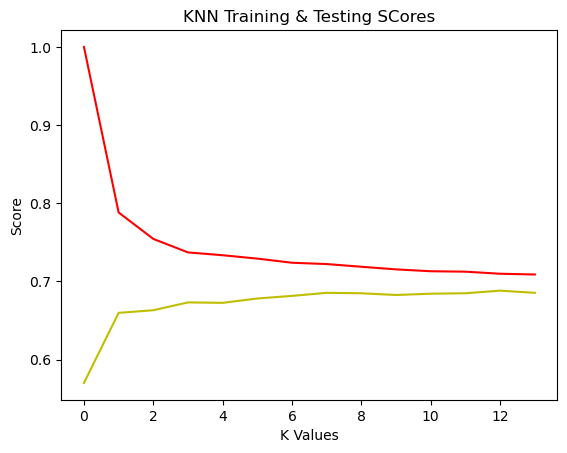

In [89]:
plt.plot(training_acc,color="r");
plt.plot(testing_acc,color="y");
plt.xlabel('K Values');
plt.ylabel('Score');
plt.title("KNN Training & Testing SCores");